# Model Reduction

In [1]:
import joblib
import json
import pandas as pd
import numpy as np
import time

model_bc = joblib.load("/home/ubuntu/DDoS_ML/training/models/knn/knn_binary_k4.joblib")

models_dir = "/home/ubuntu/DDoS_ML/training/models/knn"

with open(f"{models_dir}/features.json") as f:
    features = json.load(f)

X_test_csv = pd.read_csv(f"{models_dir}/binary_X_test.csv")
y_test_csv = pd.read_csv(f"{models_dir}/binary_y_test.csv").squeeze()

# Pick one random sample — new sample every run
rng      = np.random.default_rng()
rand_idx = int(rng.integers(len(X_test_csv)))
sample_X = X_test_csv.iloc[[rand_idx]]   # shape (1, n_features) — keeps column names
sample_y = y_test_csv.iloc[rand_idx]

# Predict and time it
t0         = time.perf_counter()
prediction = model_bc.predict(sample_X)
elapsed_ms = (time.perf_counter() - t0) * 1000

# Retrieve the k nearest neighbors (distances + indices)
nbr_dists, nbr_idxs = model_bc.kneighbors(sample_X)
nbr_dists = nbr_dists[0]
nbr_idxs  = nbr_idxs[0]

# Load training labels to show per-neighbor vote breakdown
y_train_csv = pd.read_csv(f"{models_dir}/binary_y_train.csv").squeeze()
nbr_labels  = [y_train_csv.iloc[i] for i in nbr_idxs]
vote_tally  = pd.Series(nbr_labels).value_counts().to_dict()

correct   = prediction[0] == sample_y
n_train   = model_bc.n_samples_fit_
algorithm = model_bc._fit_method

print("=" * 65)
print("  Binary KNN (k=4) — Random Test Sample")
print("=" * 65)
print(f"  Test-set index       : {rand_idx:,}  (of {len(X_test_csv):,} test samples)")
for feat, val in zip(features, sample_X.values[0]):
    print(f"  {feat:<22} : {val:.10g}")
print(f"  True label           : {sample_y}")
print(f"  Predicted label      : {prediction[0]}")
print(f"  Correct              : {'YES ✓' if correct else 'NO ✗'}")
print("-" * 65)
print(f"  Algorithm            : {algorithm}")
print(f"  Training set size    : {n_train:,}  (upper bound for brute-force)")
print(f"  k                    : {model_bc.n_neighbors} neighbors voted")
print(f"  Vote breakdown       : {vote_tally}")
for rank, (d, lbl) in enumerate(zip(nbr_dists, nbr_labels), 1):
    print(f"    N{rank}: dist={d:.6g}  label={lbl}")
print(f"  Prediction time      : {elapsed_ms:.4f} ms")
print("=" * 65)


  Binary KNN (k=4) — Random Test Sample
  Test-set index       : 172,024  (of 1,056,808 test samples)
  packet_length_max      : 60
  iat_min                : 0
  True label           : ddos
  Predicted label      : ddos
  Correct              : YES ✓
-----------------------------------------------------------------
  Algorithm            : kd_tree
  Training set size    : 4,227,229  (upper bound for brute-force)
  k                    : 4 neighbors voted
  Vote breakdown       : {'ddos': 4}
    N1: dist=0  label=ddos
    N2: dist=0  label=ddos
    N3: dist=0  label=ddos
    N4: dist=0  label=ddos
  Prediction time      : 19.2890 ms


In [2]:
import joblib
import json
import pandas as pd
import numpy as np
import time

model_mc = joblib.load("/home/ubuntu/DDoS_ML/training/models/knn/knn_multi_k3.joblib")

models_dir = "/home/ubuntu/DDoS_ML/training/models/knn"

with open(f"{models_dir}/features.json") as f:
    features = json.load(f)

X_test_csv = pd.read_csv(f"{models_dir}/multi_X_test.csv")
y_test_csv = pd.read_csv(f"{models_dir}/multi_y_test.csv").squeeze()

# Pick one random sample — new sample every run
rng      = np.random.default_rng()
rand_idx = int(rng.integers(len(X_test_csv)))
sample_X = X_test_csv.iloc[[rand_idx]]
sample_y = y_test_csv.iloc[rand_idx]

# Predict and time it
t0            = time.perf_counter()
prediction_mc = model_mc.predict(sample_X)
elapsed_ms    = (time.perf_counter() - t0) * 1000

# Retrieve the k nearest neighbors
nbr_dists, nbr_idxs = model_mc.kneighbors(sample_X)
nbr_dists = nbr_dists[0]
nbr_idxs  = nbr_idxs[0]

# Load training labels for vote breakdown
y_train_csv = pd.read_csv(f"{models_dir}/multi_y_train.csv").squeeze()
nbr_labels  = [y_train_csv.iloc[i] for i in nbr_idxs]
vote_tally  = pd.Series(nbr_labels).value_counts().to_dict()

correct   = prediction_mc[0] == sample_y
n_train   = model_mc.n_samples_fit_
algorithm = model_mc._fit_method

print("=" * 65)
print("  Multiclass KNN (k=3) — Random Test Sample")
print("=" * 65)
print(f"  Test-set index       : {rand_idx:,}  (of {len(X_test_csv):,} test samples)")
for feat, val in zip(features, sample_X.values[0]):
    print(f"  {feat:<22} : {val:.10g}")
print(f"  True label           : {sample_y}")
print(f"  Predicted label      : {prediction_mc[0]}")
print(f"  Correct              : {'YES ✓' if correct else 'NO ✗'}")
print("-" * 65)
print(f"  Algorithm            : {algorithm}")
print(f"  Training set size    : {n_train:,}  (upper bound for brute-force)")
print(f"  k                    : {model_mc.n_neighbors} neighbors voted")
print(f"  Vote breakdown       : {vote_tally}")
for rank, (d, lbl) in enumerate(zip(nbr_dists, nbr_labels), 1):
    print(f"    N{rank}: dist={d:.6g}  label={lbl}")
print(f"  Prediction time      : {elapsed_ms:.4f} ms")
print("=" * 65)


  Multiclass KNN (k=3) — Random Test Sample
  Test-set index       : 664,108  (of 1,056,808 test samples)
  packet_length_max      : 60
  iat_min                : 9.536743164e-07
  True label           : SYN
  Predicted label      : SYN
  Correct              : YES ✓
-----------------------------------------------------------------
  Algorithm            : kd_tree
  Training set size    : 4,227,229  (upper bound for brute-force)
  k                    : 3 neighbors voted
  Vote breakdown       : {'SYN': 3}
    N1: dist=0  label=SYN
    N2: dist=0  label=SYN
    N3: dist=0  label=SYN
  Prediction time      : 37.1983 ms


## 2D Scatter Plot — Training Data

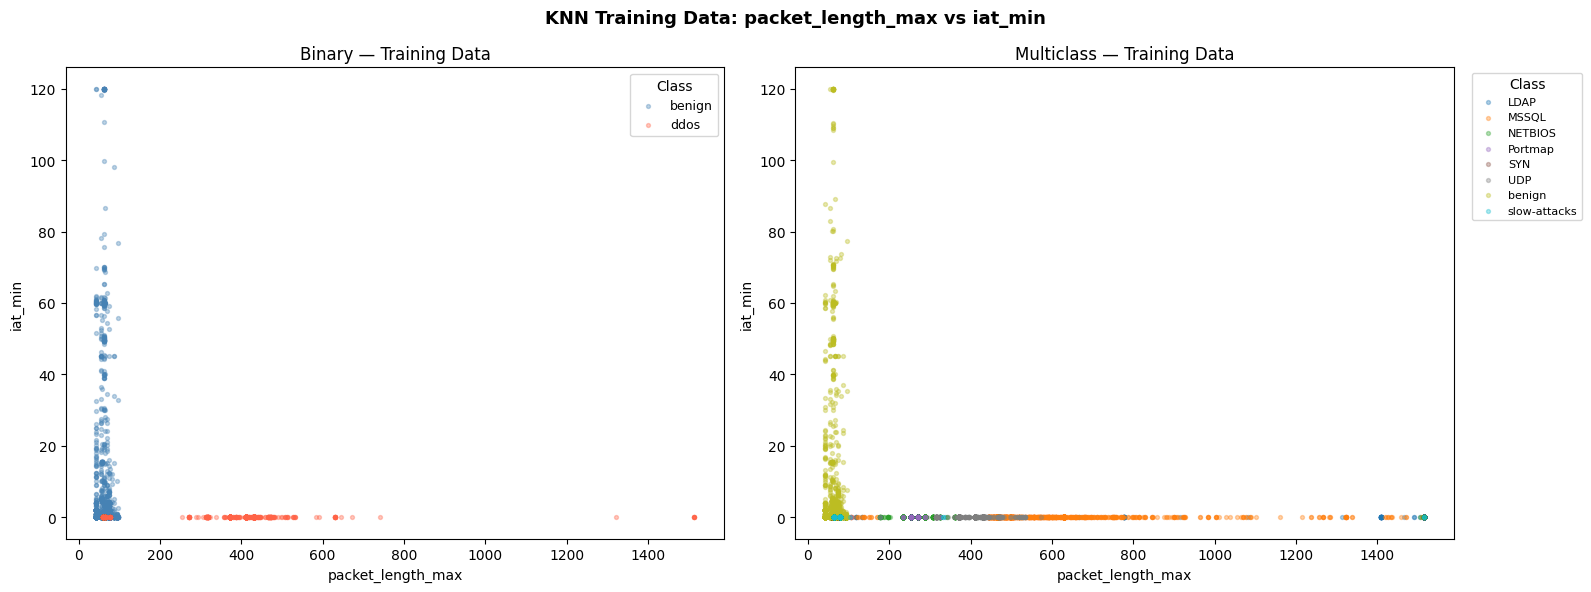

In [4]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

models_dir = "/home/ubuntu/DDoS_ML/training/models/knn"

with open(f"{models_dir}/features.json") as f:
    features = json.load(f)

feat_x, feat_y = features[0], features[1]

# Load training splits
X_bin = pd.read_csv(f"{models_dir}/binary_X_train.csv")
y_bin = pd.read_csv(f"{models_dir}/binary_y_train.csv").squeeze()

X_mc  = pd.read_csv(f"{models_dir}/multi_X_train.csv")
y_mc  = pd.read_csv(f"{models_dir}/multi_y_train.csv").squeeze()

SAMPLE_N = 4000  # points per class — keeps the plot fast

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Binary scatter ────────────────────────────────────────────────
ax = axes[0]
colors_bin = {"benign": "steelblue", "ddos": "tomato"}

for cls in sorted(y_bin.unique()):
    mask = y_bin == cls
    idx  = X_bin[mask].sample(min(SAMPLE_N, int(mask.sum())), random_state=0).index
    ax.scatter(X_bin.loc[idx, feat_x], X_bin.loc[idx, feat_y],
               color=colors_bin.get(cls, "gray"), alpha=0.35, s=8, label=cls)

ax.set_xlabel(feat_x)
ax.set_ylabel(feat_y)
ax.set_title("Binary — Training Data")
ax.legend(title="Class", fontsize=9)

# ── Multiclass scatter ────────────────────────────────────────────
ax = axes[1]
mc_classes = sorted(y_mc.unique())
palette    = plt.colormaps["tab10"].resampled(len(mc_classes))
mc_colors  = {cls: palette(i) for i, cls in enumerate(mc_classes)}

for cls in mc_classes:
    mask = y_mc == cls
    idx  = X_mc[mask].sample(min(SAMPLE_N, int(mask.sum())), random_state=0).index
    ax.scatter(X_mc.loc[idx, feat_x], X_mc.loc[idx, feat_y],
               color=mc_colors[cls], alpha=0.35, s=8, label=cls)

ax.set_xlabel(feat_x)
ax.set_ylabel(feat_y)
ax.set_title("Multiclass — Training Data")
ax.legend(title="Class", fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.suptitle(f"KNN Training Data: {feat_x} vs {feat_y}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Step 1 — Remove Redundant Points

Exact duplicate feature vectors are removed with `drop_duplicates()`.  
Two flows are duplicates when every feature value is identical (same
`packet_length_max` **and** same `iat_min`).  This collapses 4.2 M rows
down to ~960 K unique points — a **77 % reduction** — before any clustering.

In [5]:
import json
import pandas as pd
import numpy as np

models_dir = "/home/ubuntu/DDoS_ML/training/models/knn"

with open(f"{models_dir}/features.json") as f:
    features = json.load(f)

feat_x, feat_y = features[0], features[1]

# ── Binary ──────────────────────────────────────────────────────────────────
X_bin_orig = pd.read_csv(f"{models_dir}/binary_X_train.csv")
y_bin_orig = pd.read_csv(f"{models_dir}/binary_y_train.csv").squeeze()

X_bin = X_bin_orig.drop_duplicates().reset_index(drop=True)
y_bin = y_bin_orig.loc[X_bin_orig.drop_duplicates().index].reset_index(drop=True)

# ── Multiclass ───────────────────────────────────────────────────────────────
X_mc_orig = pd.read_csv(f"{models_dir}/multi_X_train.csv")
y_mc_orig = pd.read_csv(f"{models_dir}/multi_y_train.csv").squeeze()

X_mc = X_mc_orig.drop_duplicates().reset_index(drop=True)
y_mc = y_mc_orig.loc[X_mc_orig.drop_duplicates().index].reset_index(drop=True)

# ── Summary ──────────────────────────────────────────────────────────────────
print("=" * 60)
print("  Duplicate Removal Summary")
print("=" * 60)
for tag, X_orig, X_dd, y_dd in [
        ("Binary",     X_bin_orig, X_bin, y_bin),
        ("Multiclass", X_mc_orig,  X_mc,  y_mc)]:
    removed = len(X_orig) - len(X_dd)
    pct     = removed / len(X_orig) * 100
    print(f"\n  {tag}")
    print(f"    Original rows : {len(X_orig):>10,}")
    print(f"    After dedup   : {len(X_dd):>10,}  (-{removed:,} / -{pct:.1f}%)")
    print(f"    Per-class unique counts:")
    for cls, cnt in y_dd.value_counts().sort_index().items():
        print(f"      {cls:<16} : {cnt:,}")
print("=" * 60)


  Duplicate Removal Summary

  Binary
    Original rows :  4,227,229
    After dedup   :    960,154  (-3,267,075 / -77.3%)
    Per-class unique counts:
      benign           : 954,818
      ddos             : 5,336

  Multiclass
    Original rows :  4,227,229
    After dedup   :    960,574  (-3,266,655 / -77.3%)
    Per-class unique counts:
      LDAP             : 55
      MSSQL            : 1,130
      NETBIOS          : 160
      Portmap          : 3
      SYN              : 251
      UDP              : 3,719
      benign           : 955,199
      slow-attacks     : 57


## Step 2 — KMeans Centroid Reduction (k = 1–10 per class)

For each value of k (1 to 10), **KMeans** is fitted independently on
each class's deduplicated feature vectors.  The k cluster centroids replace
every original point in that class, so the final "training set" contains
at most `k × n_classes` rows.

* Binary (2 classes): 2–20 total training points  
* Multiclass (8 classes): 8–80 total training points — tiny compared to the
  original 4.2 M rows, so KNN inference becomes nearly instant.

`MiniBatchKMeans` is used for speed on the ~960 k benign points.  
Classes smaller than k use all their unique points as centroids.

In [6]:
import time
from sklearn.cluster import MiniBatchKMeans

def compute_centroids(X_dd, y_dd, k_range=range(1, 11), random_state=42):
    """Return dict  k → (X_centroids ndarray, y_centroids ndarray)."""
    results = {}
    classes = sorted(y_dd.unique())
    for k in k_range:
        Xc_list, yc_list = [], []
        for cls in classes:
            X_cls = X_dd[y_dd == cls].values
            n_cls = len(X_cls)
            actual_k = min(k, n_cls)          # can't exceed class size
            if actual_k == 1:
                Xc_list.append(X_cls.mean(axis=0, keepdims=True))
            else:
                km = MiniBatchKMeans(
                    n_clusters=actual_k, random_state=random_state,
                    n_init=5, batch_size=10_000, max_iter=300
                )
                km.fit(X_cls)
                Xc_list.append(km.cluster_centers_)
            yc_list.extend([cls] * actual_k)
        results[k] = (np.vstack(Xc_list), np.array(yc_list))
    return results

print("Computing binary centroids …")
t0 = time.perf_counter()
centroids_bin = compute_centroids(X_bin, y_bin)
print(f"  done in {time.perf_counter()-t0:.1f}s")

print("Computing multiclass centroids …")
t0 = time.perf_counter()
centroids_mc = compute_centroids(X_mc, y_mc)
print(f"  done in {time.perf_counter()-t0:.1f}s")

print()
print(f"{'k':>3}  {'Binary pts':>12}  {'Multiclass pts':>16}")
print("-" * 36)
for k in range(1, 11):
    nb = len(centroids_bin[k][0])
    nm = len(centroids_mc[k][0])
    print(f"{k:>3}  {nb:>12,}  {nm:>16,}")


Computing binary centroids …
  done in 11.1s
Computing multiclass centroids …
  done in 24.8s

  k    Binary pts    Multiclass pts
------------------------------------
  1             2                 8
  2             4                16
  3             6                24
  4             8                31
  5            10                38
  6            12                45
  7            14                52
  8            16                59
  9            18                66
 10            20                73


## Visualize Centroids — Binary (k = 1–10 per class)

Each subplot shows the **deduplicated training data** (faint background)
with the **k centroids per class** overlaid as large bold markers.
As k grows, the centroids spread out and cover more of each class's region.

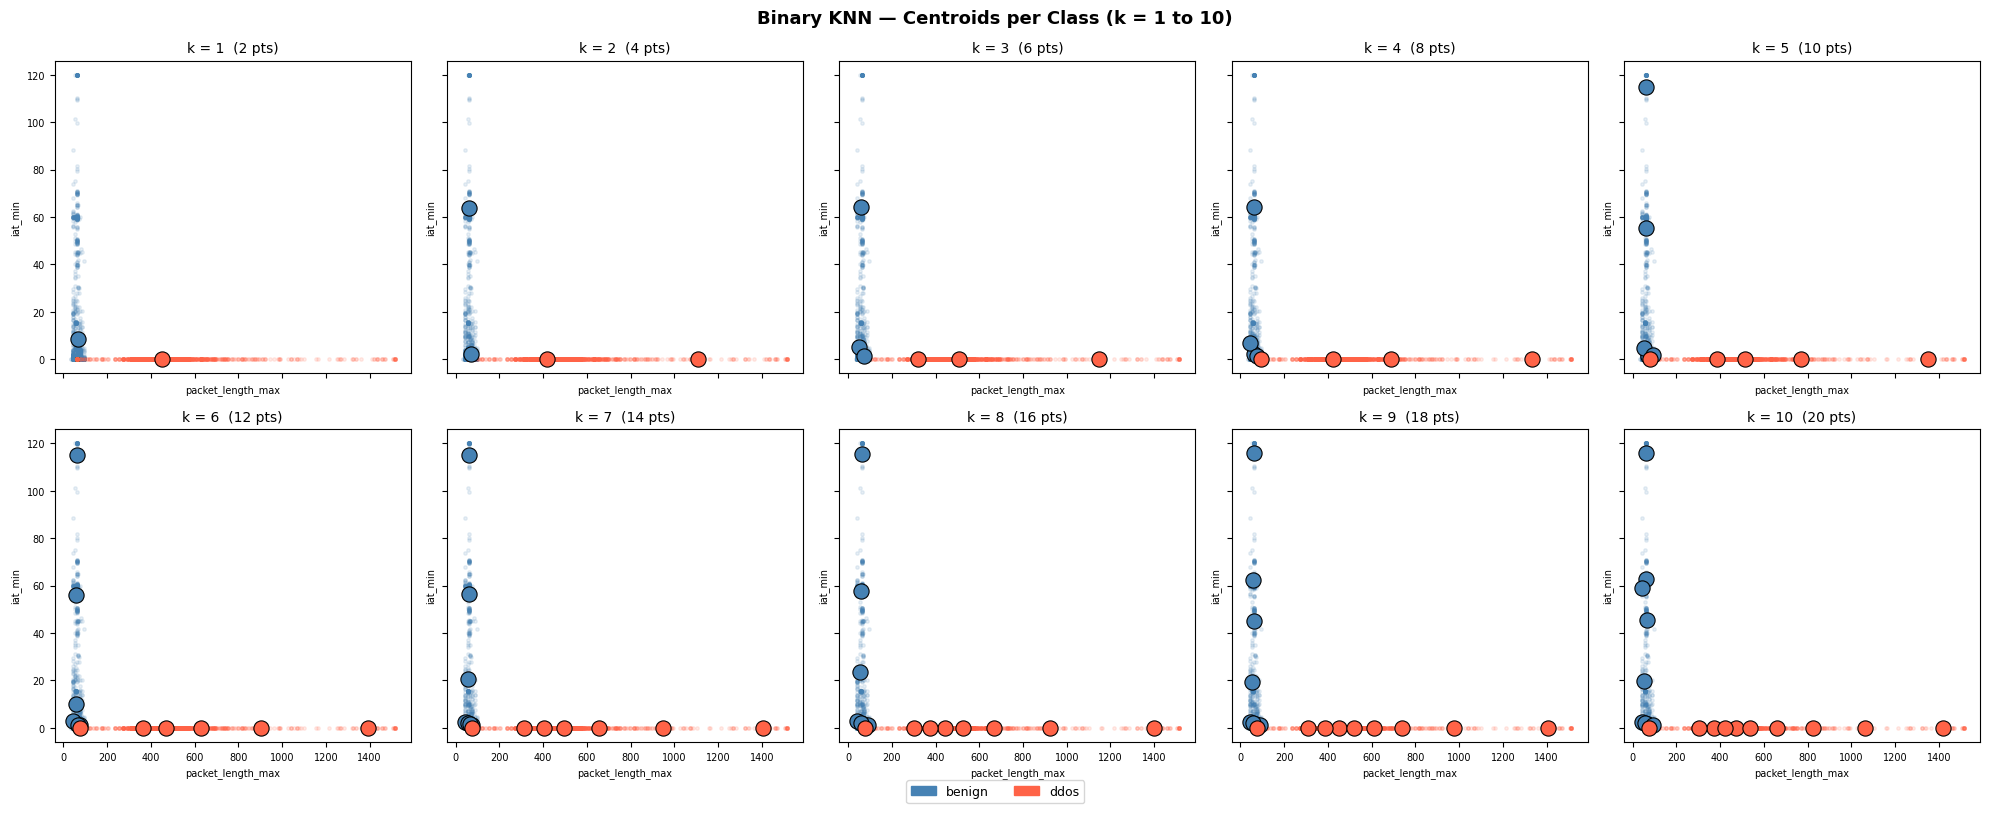

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

colors_bin = {"benign": "steelblue", "ddos": "tomato"}
bin_classes = sorted(y_bin.unique())
SAMPLE_BG = 2000   # background training points per class

# 2 rows × 5 cols → k = 1…10
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)

for idx, k in enumerate(range(1, 11)):
    ax  = axes[idx // 5][idx % 5]
    Xc, yc = centroids_bin[k]

    # Faint background: sampled deduplicated training data
    for cls in bin_classes:
        bg_idx = (y_bin == cls)
        samp   = X_bin[bg_idx].sample(min(SAMPLE_BG, int(bg_idx.sum())), random_state=0)
        ax.scatter(samp[feat_x], samp[feat_y],
                   color=colors_bin[cls], alpha=0.12, s=6, zorder=1)

    # Bold centroids
    for cls in bin_classes:
        mask = yc == cls
        ax.scatter(Xc[mask, 0], Xc[mask, 1],
                   color=colors_bin[cls], s=120, edgecolors="black",
                   linewidths=0.8, zorder=3, marker="o")

    total = len(Xc)
    ax.set_title(f"k = {k}  ({total} pts)", fontsize=10)
    ax.set_xlabel(feat_x, fontsize=7)
    ax.set_ylabel(feat_y, fontsize=7)
    ax.tick_params(labelsize=7)

handles = [mpatches.Patch(color=colors_bin[c], label=c) for c in bin_classes]
fig.legend(handles=handles, loc="lower center", ncol=2,
           fontsize=9, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Binary KNN — Centroids per Class (k = 1 to 10)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Visualize Centroids — Multiclass (k = 1–10 per class)

Same layout for the 8-class case.  Note that rare classes
(`Portmap`, `LDAP`, `slow-attacks`) have very few unique points and
hit their ceiling before k = 10.

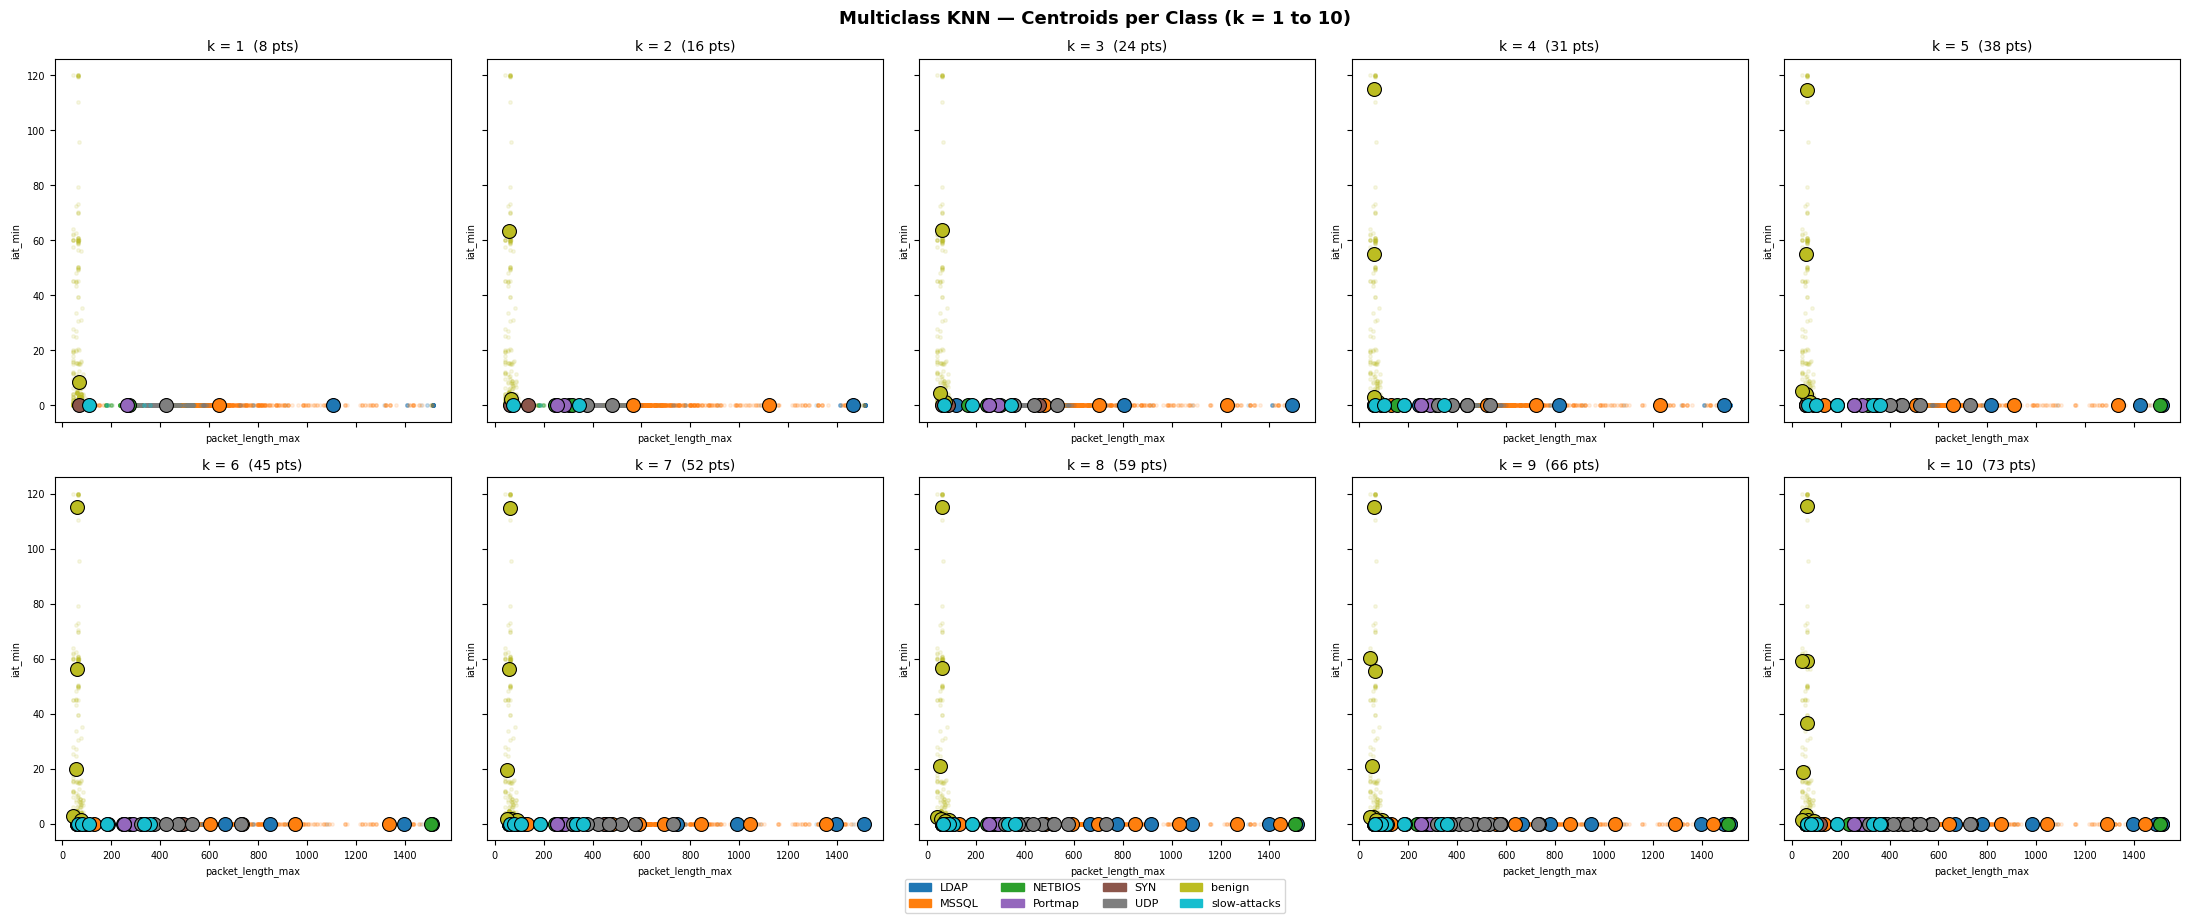

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm

mc_classes = sorted(y_mc.unique())
palette    = plt.colormaps["tab10"].resampled(len(mc_classes))
mc_colors  = {cls: palette(i) for i, cls in enumerate(mc_classes)}
SAMPLE_BG  = 800   # background per class (benign alone has 955 k unique pts)

fig, axes = plt.subplots(2, 5, figsize=(22, 9), sharex=True, sharey=True)

for idx, k in enumerate(range(1, 11)):
    ax  = axes[idx // 5][idx % 5]
    Xc, yc = centroids_mc[k]

    # Faint background
    for cls in mc_classes:
        bg_idx = (y_mc == cls)
        samp   = X_mc[bg_idx].sample(min(SAMPLE_BG, int(bg_idx.sum())), random_state=0)
        ax.scatter(samp[feat_x], samp[feat_y],
                   color=mc_colors[cls], alpha=0.12, s=6, zorder=1)

    # Bold centroids
    for cls in mc_classes:
        mask = yc == cls
        if mask.sum() == 0:
            continue
        ax.scatter(Xc[mask, 0], Xc[mask, 1],
                   color=mc_colors[cls], s=100, edgecolors="black",
                   linewidths=0.8, zorder=3, marker="o")

    total = len(Xc)
    ax.set_title(f"k = {k}  ({total} pts)", fontsize=10)
    ax.set_xlabel(feat_x, fontsize=7)
    ax.set_ylabel(feat_y, fontsize=7)
    ax.tick_params(labelsize=7)

handles = [mpatches.Patch(color=mc_colors[c], label=c) for c in mc_classes]
fig.legend(handles=handles, loc="lower center", ncol=4,
           fontsize=8, bbox_to_anchor=(0.5, -0.03))
plt.suptitle("Multiclass KNN — Centroids per Class (k = 1 to 10)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Export to CSV

In [9]:
import pandas as pd
from pathlib import Path

out_dir = Path("/home/ubuntu/DDoS_ML/training/models/knn")

for k in range(1, 11):
    # ── Binary ──────────────────────────────────────────────────────────────
    Xc_bin, yc_bin = centroids_bin[k]
    df_bin = pd.DataFrame(Xc_bin, columns=features)
    df_bin["label"] = yc_bin
    path_bin = out_dir / f"centroids_binary_k{k}.csv"
    df_bin.to_csv(path_bin, index=False)

    # ── Multiclass ───────────────────────────────────────────────────────────
    Xc_mc, yc_mc = centroids_mc[k]
    df_mc = pd.DataFrame(Xc_mc, columns=features)
    df_mc["label"] = yc_mc
    path_mc = out_dir / f"centroids_multi_k{k}.csv"
    df_mc.to_csv(path_mc, index=False)

    print(f"k={k:2d}  binary → {path_bin.name} ({len(df_bin)} rows)"
          f"   multi → {path_mc.name} ({len(df_mc)} rows)")

print("\nDone. All centroid CSVs saved to", out_dir)


k= 1  binary → centroids_binary_k1.csv (2 rows)   multi → centroids_multi_k1.csv (8 rows)
k= 2  binary → centroids_binary_k2.csv (4 rows)   multi → centroids_multi_k2.csv (16 rows)
k= 3  binary → centroids_binary_k3.csv (6 rows)   multi → centroids_multi_k3.csv (24 rows)
k= 4  binary → centroids_binary_k4.csv (8 rows)   multi → centroids_multi_k4.csv (31 rows)
k= 5  binary → centroids_binary_k5.csv (10 rows)   multi → centroids_multi_k5.csv (38 rows)
k= 6  binary → centroids_binary_k6.csv (12 rows)   multi → centroids_multi_k6.csv (45 rows)
k= 7  binary → centroids_binary_k7.csv (14 rows)   multi → centroids_multi_k7.csv (52 rows)
k= 8  binary → centroids_binary_k8.csv (16 rows)   multi → centroids_multi_k8.csv (59 rows)
k= 9  binary → centroids_binary_k9.csv (18 rows)   multi → centroids_multi_k9.csv (66 rows)
k=10  binary → centroids_binary_k10.csv (20 rows)   multi → centroids_multi_k10.csv (73 rows)

Done. All centroid CSVs saved to /home/ubuntu/DDoS_ML/training/models/knn


## Performance vs Number of Centroids

Classify the full test set using each centroid CSV as the KNN training set.
One row per centroid count (1–10 per class) for both binary and multiclass.

KNN `k` is capped at the number of available training points when the centroid
set is smaller than the original `k` (e.g. binary with 1 centroid/class = 2 total points).

In [11]:
import json
import time
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models_dir = Path("/home/ubuntu/DDoS_ML/training/models/knn")

with open(models_dir / "features.json") as f:
    features = json.load(f)

X_test_bin = pd.read_csv(models_dir / "binary_X_test.csv")
y_test_bin = pd.read_csv(models_dir / "binary_y_test.csv").squeeze()
n_test_bin = len(X_test_bin)

X_test_mc  = pd.read_csv(models_dir / "multi_X_test.csv")
y_test_mc  = pd.read_csv(models_dir / "multi_y_test.csv").squeeze()
n_test_mc  = len(X_test_mc)

# ─── Binary ────────────────────────────────────────────────────────────────────
# k = n for n < 4, k = 4 for n >= 4
print("Evaluating binary …")
bin_rows = []
for n in range(1, 11):
    df_c  = pd.read_csv(models_dir / f"centroids_binary_k{n}.csv")
    Xc    = df_c[features].values
    yc    = df_c["label"].values
    knn_k = n if n < 4 else 4

    knn = KNeighborsClassifier(n_neighbors=knn_k, n_jobs=-1)
    knn.fit(Xc, yc)

    t0     = time.perf_counter()
    y_pred = knn.predict(X_test_bin.values)
    t_ms   = (time.perf_counter() - t0) * 1000

    bin_rows.append({
        "k/class":         n,
        "Train pts":       len(Xc),
        "KNN k":           knn_k,
        "Accuracy":        round(accuracy_score(y_test_bin, y_pred), 4),
        "Precision":       round(precision_score(y_test_bin, y_pred, pos_label="ddos", zero_division=0), 4),
        "Recall":          round(recall_score(y_test_bin, y_pred, pos_label="ddos", zero_division=0), 4),
        "F1":              round(f1_score(y_test_bin, y_pred, pos_label="ddos", zero_division=0), 4),
        "Total time (ms)": round(t_ms, 1),
        "Avg time (µs)":   round(t_ms * 1000 / n_test_bin, 3),
    })
    print(f"  n={n:2d}  pts={len(Xc):>3}  k={knn_k}  "
          f"F1={bin_rows[-1]['F1']:.4f}  avg={bin_rows[-1]['Avg time (µs)']:.3f} µs")

df_bin = pd.DataFrame(bin_rows).set_index("k/class")

# ─── Multiclass ────────────────────────────────────────────────────────────────
# k = n for n < 3, k = 3 for n >= 3
print("\nEvaluating multiclass …")
mc_rows = []
for n in range(1, 11):
    df_c  = pd.read_csv(models_dir / f"centroids_multi_k{n}.csv")
    Xc    = df_c[features].values
    yc    = df_c["label"].values
    knn_k = n if n < 3 else 3

    knn = KNeighborsClassifier(n_neighbors=knn_k, n_jobs=-1)
    knn.fit(Xc, yc)

    t0     = time.perf_counter()
    y_pred = knn.predict(X_test_mc.values)
    t_ms   = (time.perf_counter() - t0) * 1000

    mc_rows.append({
        "k/class":         n,
        "Train pts":       len(Xc),
        "KNN k":           knn_k,
        "Accuracy":        round(accuracy_score(y_test_mc, y_pred), 4),
        "Precision":       round(precision_score(y_test_mc, y_pred, average="macro", zero_division=0), 4),
        "Recall":          round(recall_score(y_test_mc, y_pred, average="macro", zero_division=0), 4),
        "F1 (macro)":      round(f1_score(y_test_mc, y_pred, average="macro", zero_division=0), 4),
        "Total time (ms)": round(t_ms, 1),
        "Avg time (µs)":   round(t_ms * 1000 / n_test_mc, 3),
    })
    print(f"  n={n:2d}  pts={len(Xc):>3}  k={knn_k}  "
          f"F1={mc_rows[-1]['F1 (macro)']:.4f}  avg={mc_rows[-1]['Avg time (µs)']:.3f} µs")

df_mc = pd.DataFrame(mc_rows).set_index("k/class")

# ─── Display tables ────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  Binary KNN — Test Performance vs Centroids per Class")
print("=" * 70)
display(df_bin)

print("\n" + "=" * 70)
print("  Multiclass KNN — Test Performance vs Centroids per Class (macro-avg)")
print("=" * 70)
display(df_mc)


Evaluating binary …
  n= 1  pts=  2  k=1  F1=0.8242  avg=12.225 µs
  n= 2  pts=  4  k=2  F1=0.0081  avg=12.603 µs
  n= 3  pts=  6  k=3  F1=0.8230  avg=13.664 µs
  n= 4  pts=  8  k=4  F1=0.6223  avg=13.084 µs
  n= 5  pts= 10  k=4  F1=0.8229  avg=13.199 µs
  n= 6  pts= 12  k=4  F1=0.8242  avg=13.492 µs
  n= 7  pts= 14  k=4  F1=0.8244  avg=12.844 µs
  n= 8  pts= 16  k=4  F1=0.8244  avg=12.920 µs
  n= 9  pts= 18  k=4  F1=0.8244  avg=12.870 µs
  n=10  pts= 20  k=4  F1=0.8244  avg=12.920 µs

Evaluating multiclass …
  n= 1  pts=  8  k=1  F1=0.4268  avg=12.149 µs
  n= 2  pts= 16  k=2  F1=0.3874  avg=12.703 µs
  n= 3  pts= 24  k=3  F1=0.1789  avg=12.853 µs
  n= 4  pts= 31  k=3  F1=0.2693  avg=12.880 µs
  n= 5  pts= 38  k=3  F1=0.2669  avg=13.018 µs
  n= 6  pts= 45  k=3  F1=0.2419  avg=12.960 µs
  n= 7  pts= 52  k=3  F1=0.3009  avg=13.090 µs
  n= 8  pts= 59  k=3  F1=0.2826  avg=13.994 µs
  n= 9  pts= 66  k=3  F1=0.2717  avg=12.994 µs
  n=10  pts= 73  k=3  F1=0.2818  avg=13.014 µs

  Binary KNN —

,Train pts,KNN k,Accuracy,Precision,Recall,F1,Total time (ms),Avg time (µs)
k/class,,,,,,,,
1,2,1,0.8411,1.0,0.7009,0.8242,12919.4,12.225
2,4,2,0.4709,1.0,0.0040,0.0081,13318.4,12.603
3,6,3,0.8402,1.0,0.6993,0.8230,14440.3,13.664
4,8,4,0.7087,1.0,0.4517,0.6223,13827.1,13.084
5,10,4,0.8401,1.0,0.6990,0.8229,13948.8,13.199
6,12,4,0.8411,1.0,0.7009,0.8242,14258.0,13.492
7,14,4,0.8413,1.0,0.7013,0.8244,13573.1,12.844
8,16,4,0.8413,1.0,0.7013,0.8244,13654.1,12.920
9,18,4,0.8413,1.0,0.7013,0.8244,13601.5,12.870



  Multiclass KNN — Test Performance vs Centroids per Class (macro-avg)


,Train pts,KNN k,Accuracy,Precision,Recall,F1 (macro),Total time (ms),Avg time (µs)
k/class,,,,,,,,
1,8,1,0.5547,0.5165,0.5614,0.4268,12839.2,12.149
2,16,2,0.7685,0.4216,0.5464,0.3874,13424.7,12.703
3,24,3,0.4122,0.2901,0.4988,0.1789,13583.3,12.853
4,31,3,0.5290,0.3378,0.5418,0.2693,13611.9,12.880
5,38,3,0.5801,0.3222,0.5052,0.2669,13757.9,13.018
6,45,3,0.4224,0.3352,0.4873,0.2419,13695.9,12.960
7,52,3,0.5205,0.3573,0.5769,0.3009,13834.0,13.090
8,59,3,0.4860,0.3481,0.4846,0.2826,14788.5,13.994
9,66,3,0.4831,0.4167,0.5774,0.2717,13732.0,12.994


## Complexity Analysis per Centroid Count

For each scenario (k centroids per class, binary and multiclass) we compute:

| Metric | Formula |
|--------|---------|
| **Distances / query** | N_train (brute-force: one per training point) |
| **FLOPs / query** | N_train × (3d−1) + N_train = 6 × N_train for d=2 |
| **Instructions / query** | ~3 × FLOPs (load + compute + store per op) |
| **Time complexity** | O(N_train × d) = O(N_train) for fixed d=2 |
| **Space** | N_train × d × 4 bytes (float32) |
| **Energy / prediction** | P_core × t_inference — assumes 15 W single core under load |

> Timing is re-measured here on 10 000 test samples (5 runs averaged) so this
> cell runs fast and independently of the evaluation cell above.

In [12]:
import json
import time
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.neighbors import KNeighborsClassifier
from IPython.display import display

models_dir = Path("/home/ubuntu/DDoS_ML/training/models/knn")

with open(models_dir / "features.json") as f:
    features = json.load(f)

d            = len(features)    # 2 features
CPU_POWER_W  = 15.0             # assumed single-core power under load (W)
BYTES_FLOAT  = 4                # float32
TIMING_N     = 10_000           # samples used for fast re-timing

X_time_bin = pd.read_csv(models_dir / "binary_X_test.csv").head(TIMING_N).values
X_time_mc  = pd.read_csv(models_dir / "multi_X_test.csv").head(TIMING_N).values

def measure_us(knn, X, repeats=5):
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        knn.predict(X)
        times.append((time.perf_counter() - t0) * 1e6)
    return np.mean(times) / len(X)   # µs per sample

def build_row(n, N_train, knn_k, avg_us, label):
    # Distance: d subtractions + d squarings + (d-1) additions = 3d-1 ops
    flops_per_dist  = 3 * d - 1
    # k-selection: linear scan through N_train distances
    flops_kselect   = N_train
    total_flops     = N_train * flops_per_dist + flops_kselect
    # ~3 machine instructions per FLOP (load + compute + store)
    instructions    = total_flops * 3
    # float32 storage for centroid coordinates only
    space_bytes     = N_train * d * BYTES_FLOAT
    # E = P × t  (15 W × avg_µs → µJ)
    energy_uJ       = CPU_POWER_W * avg_us * 1e-6 * 1e6

    return {
        "Model":             label,
        "k/class":           n,
        "N_train":           N_train,
        "KNN k":             knn_k,
        "Dist/query":        N_train,
        "FLOPs/query":       total_flops,
        "Instrs/query":      instructions,
        "Time O()":          f"O({N_train}x{d})",
        "Space (bytes)":     space_bytes,
        "Avg time (us)":     round(avg_us, 3),
        "Energy/pred (uJ)":  round(energy_uJ, 3),
    }

rows = []

print("Timing binary scenarios ...")
for n in range(1, 11):
    df_c  = pd.read_csv(models_dir / f"centroids_binary_k{n}.csv")
    Xc, yc = df_c[features].values, df_c["label"].values
    knn_k   = n if n < 4 else 4
    knn = KNeighborsClassifier(n_neighbors=knn_k, n_jobs=-1)
    knn.fit(Xc, yc)
    avg_us = measure_us(knn, X_time_bin)
    rows.append(build_row(n, len(Xc), knn_k, avg_us, "binary"))
    print(f"  n={n:2d}  N={len(Xc):>3}  k={knn_k}  {avg_us:.3f} us  "
          f"FLOPs={rows[-1]['FLOPs/query']}  Energy={rows[-1]['Energy/pred (uJ)']:.3f} uJ")

print("\nTiming multiclass scenarios ...")
for n in range(1, 11):
    df_c  = pd.read_csv(models_dir / f"centroids_multi_k{n}.csv")
    Xc, yc = df_c[features].values, df_c["label"].values
    knn_k   = n if n < 3 else 3
    knn = KNeighborsClassifier(n_neighbors=knn_k, n_jobs=-1)
    knn.fit(Xc, yc)
    avg_us = measure_us(knn, X_time_mc)
    rows.append(build_row(n, len(Xc), knn_k, avg_us, "multiclass"))
    print(f"  n={n:2d}  N={len(Xc):>3}  k={knn_k}  {avg_us:.3f} us  "
          f"FLOPs={rows[-1]['FLOPs/query']}  Energy={rows[-1]['Energy/pred (uJ)']:.3f} uJ")

df_all = pd.DataFrame(rows)

print("\n" + "=" * 75)
print("  BINARY — Complexity per Centroid Count")
print("=" * 75)
df_bin = df_all[df_all["Model"] == "binary"].drop(columns="Model").set_index("k/class")
display(df_bin)

print("\n" + "=" * 75)
print("  MULTICLASS — Complexity per Centroid Count")
print("=" * 75)
df_mc = df_all[df_all["Model"] == "multiclass"].drop(columns="Model").set_index("k/class")
display(df_mc)

print(f"""
Notes
-----
FLOPs/query  = N_train x (3d-1) + N_train = {3*d} x N_train   (d={d} features, brute-force)
Instrs/query ~ 3 x FLOPs  (load + compute + store; ignores SIMD vectorisation)
Space        = N_train x d x 4 bytes  (float32 centroids; excludes sklearn object overhead)
Energy       = {CPU_POWER_W} W x avg_inference_time  (single core under load)
               Includes Python/sklearn overhead -- a C implementation would be ~1000x lower.
""")


Timing binary scenarios ...
  n= 1  N=  2  k=1  12.473 us  FLOPs=12  Energy=187.091 uJ
  n= 2  N=  4  k=2  12.651 us  FLOPs=24  Energy=189.772 uJ
  n= 3  N=  6  k=3  12.937 us  FLOPs=36  Energy=194.056 uJ
  n= 4  N=  8  k=4  12.731 us  FLOPs=48  Energy=190.963 uJ
  n= 5  N= 10  k=4  14.305 us  FLOPs=60  Energy=214.573 uJ
  n= 6  N= 12  k=4  14.767 us  FLOPs=72  Energy=221.503 uJ
  n= 7  N= 14  k=4  14.721 us  FLOPs=84  Energy=220.814 uJ
  n= 8  N= 16  k=4  14.657 us  FLOPs=96  Energy=219.850 uJ
  n= 9  N= 18  k=4  14.449 us  FLOPs=108  Energy=216.731 uJ
  n=10  N= 20  k=4  14.373 us  FLOPs=120  Energy=215.592 uJ

Timing multiclass scenarios ...
  n= 1  N=  8  k=1  13.694 us  FLOPs=48  Energy=205.416 uJ
  n= 2  N= 16  k=2  14.133 us  FLOPs=96  Energy=211.999 uJ
  n= 3  N= 24  k=3  15.189 us  FLOPs=144  Energy=227.835 uJ
  n= 4  N= 31  k=3  14.555 us  FLOPs=186  Energy=218.331 uJ
  n= 5  N= 38  k=3  14.366 us  FLOPs=228  Energy=215.484 uJ
  n= 6  N= 45  k=3  14.497 us  FLOPs=270  Energy=

,N_train,KNN k,Dist/query,FLOPs/query,Instrs/query,Time O(),Space (bytes),Avg time (us),Energy/pred (uJ)
k/class,,,,,,,,,
1,2,1,2,12,36,O(2x2),16,12.473,187.091
2,4,2,4,24,72,O(4x2),32,12.651,189.772
3,6,3,6,36,108,O(6x2),48,12.937,194.056
4,8,4,8,48,144,O(8x2),64,12.731,190.963
5,10,4,10,60,180,O(10x2),80,14.305,214.573
6,12,4,12,72,216,O(12x2),96,14.767,221.503
7,14,4,14,84,252,O(14x2),112,14.721,220.814
8,16,4,16,96,288,O(16x2),128,14.657,219.850
9,18,4,18,108,324,O(18x2),144,14.449,216.731



  MULTICLASS — Complexity per Centroid Count


,N_train,KNN k,Dist/query,FLOPs/query,Instrs/query,Time O(),Space (bytes),Avg time (us),Energy/pred (uJ)
k/class,,,,,,,,,
1,8,1,8,48,144,O(8x2),64,13.694,205.416
2,16,2,16,96,288,O(16x2),128,14.133,211.999
3,24,3,24,144,432,O(24x2),192,15.189,227.835
4,31,3,31,186,558,O(31x2),248,14.555,218.331
5,38,3,38,228,684,O(38x2),304,14.366,215.484
6,45,3,45,270,810,O(45x2),360,14.497,217.453
7,52,3,52,312,936,O(52x2),416,14.313,214.690
8,59,3,59,354,1062,O(59x2),472,14.565,218.471
9,66,3,66,396,1188,O(66x2),528,14.176,212.641



Notes
-----
FLOPs/query  = N_train x (3d-1) + N_train = 6 x N_train   (d=2 features, brute-force)
Instrs/query ~ 3 x FLOPs  (load + compute + store; ignores SIMD vectorisation)
Space        = N_train x d x 4 bytes  (float32 centroids; excludes sklearn object overhead)
Energy       = 15.0 W x avg_inference_time  (single core under load)
               Includes Python/sklearn overhead -- a C implementation would be ~1000x lower.

